# Run all notebooks in the project

# Series01-Python-Git


Shape: (6500, 3)


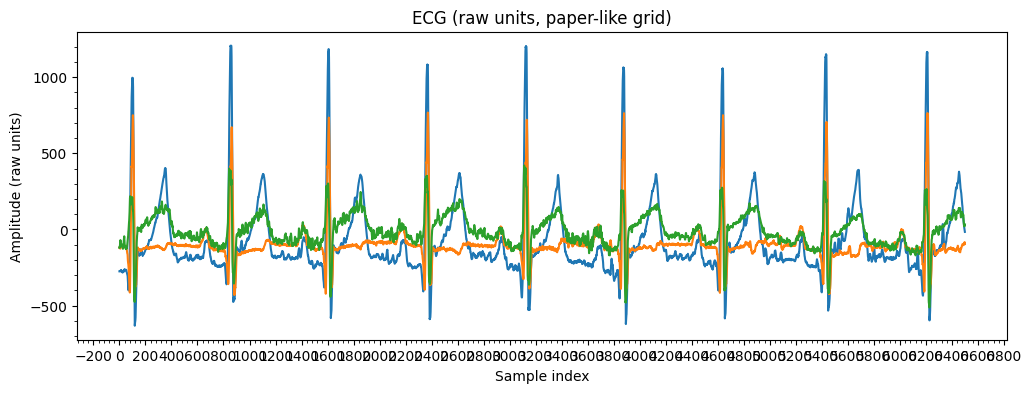

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# lire le txt -> tableau (N, 3) attendu
ecg = np.loadtxt(ECG_FILE)

print("Shape:", ecg.shape)   # ex: (6500, 3)

fig, ax = plt.subplots(figsize=(12, 4))

# tracer les 3 dérivations superposées
ax.plot(ecg)

# grille type ECG
ax.xaxis.set_major_locator(MultipleLocator(200))   # 0.2 s si 1000 Hz
ax.xaxis.set_minor_locator(MultipleLocator(40))    # 0.04 s
ax.yaxis.set_major_locator(MultipleLocator(500))   # 0.5 mV ≈ 500 raw units
ax.yaxis.set_minor_locator(MultipleLocator(100))   # 0.1 mV ≈ 100 raw units



# titres
ax.set_title("ECG (raw units, paper-like grid)")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude (raw units)")

plt.show()

In [14]:
 #Sous-problèmes (du but à la source):
# 1) tracer le signal
# 2) charger le fichier texte dans un tableau numpy
# 3) importer les bibliothèques
# 4) définir le nom du fichier et le dossier

# Algorithme:
# - importer numpy et matplotlib
# - définir le chemin du fichier
# - charger le fichier dans un tableau numpy
# - tracer le signal

In [15]:
fs = 1000.0  # Hz
mV_per_unit = 1024.0 / 1000.0  # 1024 µV = 1.024 mV

# ecg_mV a la même shape que ecg : (N, 3)
ecg_mV = ecg * mV_per_unit

N = ecg_mV.shape[0]
t = np.arange(N) / fs  # secondes

print("t shape:", t.shape, "— first/last:", t[0], t[-1], "secs")
print("mV per unit:", mV_per_unit)

t shape: (6500,) — first/last: 0.0 6.499 secs
mV per unit: 1.024


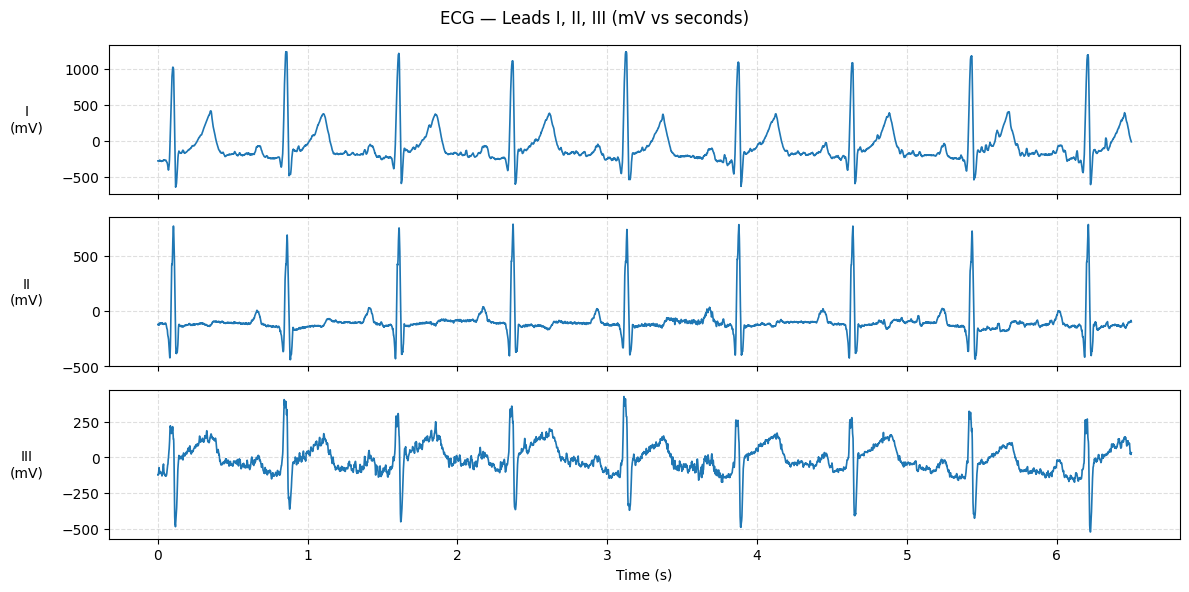

In [24]:
lead_names = ["I", "II", "III"]

# couleur des grilles (comme sur un ECG papier)
ax.grid(which="major", color="#ff4d4d", linewidth=1.0)
ax.grid(which="minor", color="#ffcccc", linewidth=0.5)

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
# couleur des grilles (comme sur un ECG papier)

for i, ax in enumerate(axes):
    ax.plot(t, ecg_mV[:, i], linewidth=1.2)
    ax.set_ylabel(f"{lead_names[i]}\n(mV)", rotation=0, labelpad=25, va="center")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)


axes[-1].set_xlabel("Time (s)")


fig.suptitle("ECG — Leads I, II, III (mV vs seconds)", y=0.98)
fig.tight_layout()
plt.show()